<a href="https://colab.research.google.com/github/fox-buddy/MachineLearning-Collection/blob/spaceship-titanic/spaceship_minimal_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd

In [66]:
X_train = pd.read_csv('/content/SpaceshipTitanic/X_train_splitted.csv')
X_test = pd.read_csv('/content/SpaceshipTitanic/X_test_splitted.csv')


X_train_raw = pd.read_csv('/content/SpaceshipTitanic/train.csv')
X_test_raw = pd.read_csv('/content/SpaceshipTitanic/test.csv')

In [67]:
X_train_raw.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [68]:
y_train = X_train_raw["Transported"]

In [69]:
y_train

,Transported
0,False
1,True
2,False
3,False
4,True
...,...
8688,False
8689,False
8690,True
8691,False


In [70]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,groupid,deck,deckroom,deckside
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,1,B,0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,2,F,0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,A,0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,A,0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,4,F,1,S


In [71]:
X_train_raw.Transported.value_counts()

,count
Transported,
True,4378
False,4315


In [72]:
X_train = X_train.drop(columns=["deckroom", "deckside"])
X_test = X_test.drop(columns=["deckroom", "deckside"])

In [12]:
# imports for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

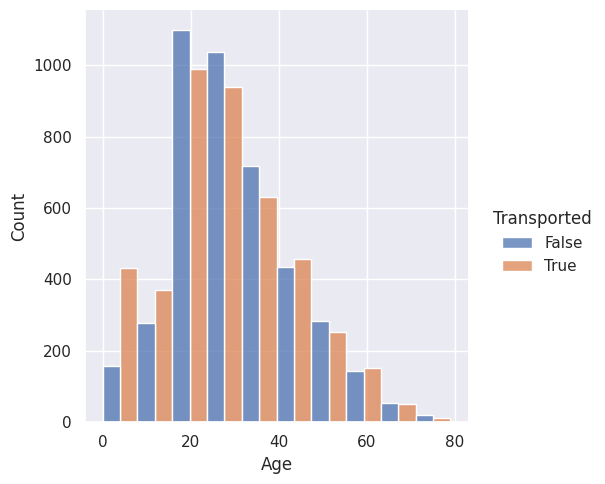

In [73]:
# showing distribution of numerical values. Number of bins will automatically be determined based on data structure
sns.displot(X_train_raw, x="Age", bins=10, hue="Transported", multiple="dodge")

# transported is basically toggled at age 20

In [74]:
X_train.Age.value_counts()

,count
Age,
24.0,324
18.0,320
21.0,311
19.0,293
23.0,292
...,...
75.0,4
79.0,3
78.0,3


In [75]:
# Binning Age
age_bins = [0, 4, 12, 18, 25, 40, 50, 60, 80]
age_labels = ['Baby', 'Child', 'Teenager', 'Young Adult', 'Adult', 'Prime Aduld', 'Senior', 'Elder']

In [76]:
X_train_raw["AgeGroup"] = pd.cut(X_train_raw.Age, bins=age_bins, labels=age_labels, include_lowest=True)

In [17]:
X_train["AgeGroup"] = pd.cut(X_train_raw.Age, bins=age_bins, labels=age_labels, include_lowest=True)
X_test["AgeGroup"] = pd.cut(X_test.Age, bins=age_bins, labels=age_labels, include_lowest=True)

In [18]:
X_train = X_train.drop(columns=["Age"])
X_test = X_test.drop(columns=["Age"])

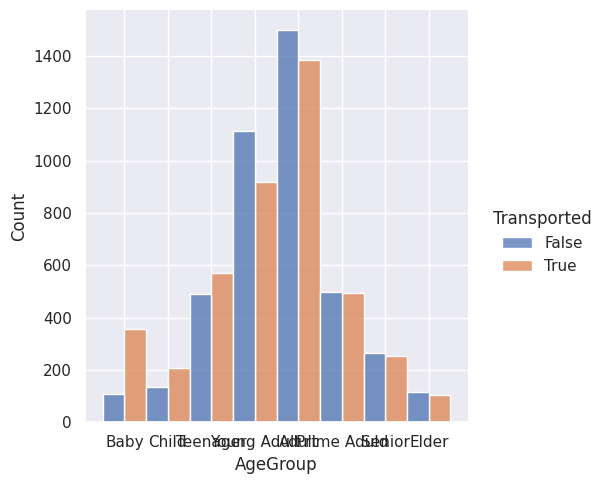

In [19]:
sns.displot(X_train_raw, x="AgeGroup", bins=10, hue="Transported", multiple="dodge")


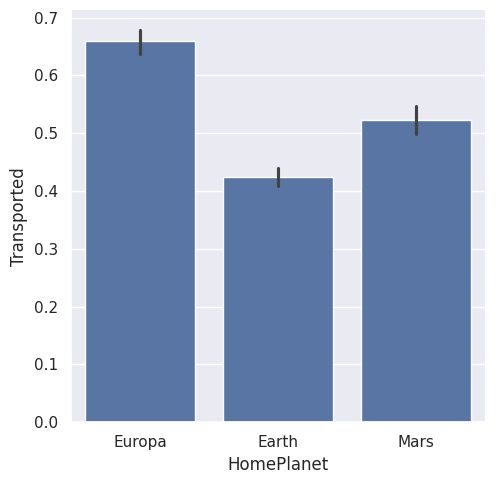

In [20]:
sns.catplot(data=X_train_raw, x="HomePlanet", y="Transported", kind="bar")

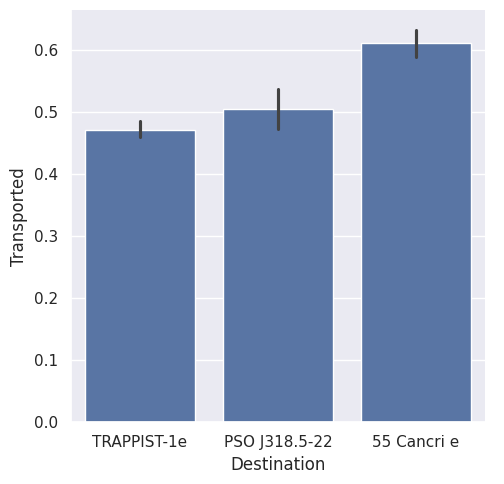

In [21]:
sns.catplot(data=X_train_raw, x="Destination", y="Transported", kind="bar")

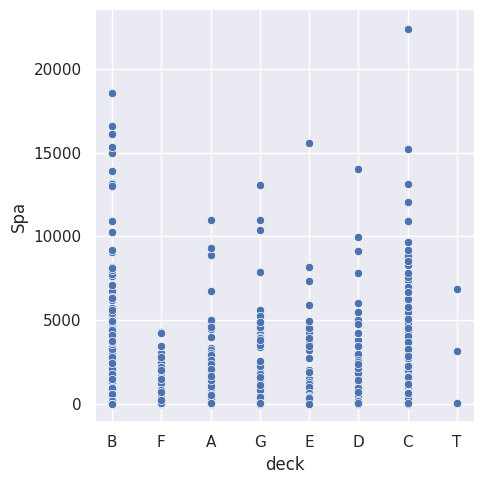

In [22]:
sns.relplot(X_train, x="deck", y="Spa")

In [23]:
X_train_raw.corr(numeric_only=True)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


In [24]:
X_train = X_train.drop(columns=["FoodCourt", "ShoppingMall"])
X_test = X_test.drop(columns=["FoodCourt", "ShoppingMall"])

In [25]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
0,0001_01,Europa,False,TRAPPIST-1e,False,0.0,0.0,0.0,1,B,Adult
1,0002_01,Earth,False,TRAPPIST-1e,False,109.0,549.0,44.0,2,F,Young Adult
2,0003_01,Europa,False,TRAPPIST-1e,True,43.0,6715.0,49.0,3,A,Senior
3,0003_02,Europa,False,TRAPPIST-1e,False,0.0,3329.0,193.0,3,A,Adult
4,0004_01,Earth,False,TRAPPIST-1e,False,303.0,565.0,2.0,4,F,Teenager


In [26]:
# Data looks good here
# now scaling, imputing and encoding

X_test.set_index("PassengerId")

,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
PassengerId,,,,,,,,,,
0013_01,Earth,True,TRAPPIST-1e,False,0.0,0.0,0.0,13,G,Adult
0018_01,Earth,False,TRAPPIST-1e,False,0.0,2823.0,0.0,18,F,Young Adult
0019_01,Europa,True,55 Cancri e,False,0.0,0.0,0.0,19,C,Adult
0021_01,Europa,False,TRAPPIST-1e,False,0.0,181.0,585.0,21,C,Adult
0023_01,Earth,False,TRAPPIST-1e,False,10.0,0.0,0.0,23,F,Young Adult
...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,TRAPPIST-1e,False,0.0,0.0,0.0,9266,G,Adult
9269_01,Earth,False,TRAPPIST-1e,False,0.0,10.0,144.0,9269,G,Prime Aduld
9271_01,Mars,True,55 Cancri e,False,0.0,0.0,0.0,9271,D,NaN


In [27]:
X_train.set_index("PassengerId")

,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
PassengerId,,,,,,,,,,
0001_01,Europa,False,TRAPPIST-1e,False,0.0,0.0,0.0,1,B,Adult
0002_01,Earth,False,TRAPPIST-1e,False,109.0,549.0,44.0,2,F,Young Adult
0003_01,Europa,False,TRAPPIST-1e,True,43.0,6715.0,49.0,3,A,Senior
0003_02,Europa,False,TRAPPIST-1e,False,0.0,3329.0,193.0,3,A,Adult
0004_01,Earth,False,TRAPPIST-1e,False,303.0,565.0,2.0,4,F,Teenager
...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,55 Cancri e,True,0.0,1643.0,74.0,9276,A,Prime Aduld
9278_01,Earth,True,PSO J318.5-22,False,0.0,0.0,0.0,9278,G,Teenager
9279_01,Earth,False,TRAPPIST-1e,False,0.0,1.0,0.0,9279,G,Adult


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  8693 non-null   object  
 1   HomePlanet   8492 non-null   object  
 2   CryoSleep    8476 non-null   object  
 3   Destination  8511 non-null   object  
 4   VIP          8490 non-null   object  
 5   RoomService  8512 non-null   float64 
 6   Spa          8510 non-null   float64 
 7   VRDeck       8505 non-null   float64 
 8   groupid      8693 non-null   int64   
 9   deck         8693 non-null   object  
 10  AgeGroup     8514 non-null   category
dtypes: category(1), float64(3), int64(1), object(6)
memory usage: 688.1+ KB


In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn. preprocessing import StandardScaler

num_columns = ["RoomService", "Spa", "VRDeck"]
cat_cols_unknown_encode = ["HomePlanet", "Destination"]
cat_cols_mf_encode = ["AgeGroup", "VIP", "CryoSleep"]
cat_cols_only_encode = ["groupid", "deck"]

In [30]:
num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer(strategy="mean"))
    , ("num_scaler", StandardScaler())
])

cat_pipeline_unknown = Pipeline([
    ("cat_unk_imputer", SimpleImputer(strategy="constant", fill_value='unknown'))
    , ("cat_unk_encoder", OneHotEncoder())
])

cat_pipeline_mostfrequent = Pipeline([
    ("cat_mf_imputer", SimpleImputer(strategy="most_frequent"))
    , ("cat_unk_encoder", OneHotEncoder())
])

cat_pipeline_only = Pipeline([
    ("cat_only_encoder", OneHotEncoder())
])

In [31]:
from sklearn.compose import ColumnTransformer

data_col_transformer = ColumnTransformer([
    ("num_transformer", num_pipeline, num_columns)
    , ("cat_unkimpute_transformer", cat_pipeline_unknown, cat_cols_unknown_encode)
    , ("cat_mfimpute_transformer", cat_pipeline_mostfrequent, cat_cols_mf_encode)
    , ("cat_onlyencode_transformer", cat_pipeline_only, cat_cols_only_encode)
])

In [32]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  8693 non-null   object  
 1   HomePlanet   8492 non-null   object  
 2   CryoSleep    8476 non-null   object  
 3   Destination  8511 non-null   object  
 4   VIP          8490 non-null   object  
 5   RoomService  8512 non-null   float64 
 6   Spa          8510 non-null   float64 
 7   VRDeck       8505 non-null   float64 
 8   groupid      8693 non-null   int64   
 9   deck         8693 non-null   object  
 10  AgeGroup     8514 non-null   category
dtypes: category(1), float64(3), int64(1), object(6)
memory usage: 688.1+ KB


In [33]:
X_train_prepared = data_col_transformer.fit_transform(X_train)

In [34]:
X_test_prepared = data_col_transformer.fit_transform(X_test)

In [35]:
from sklearn.model_selection import cross_val_score

In [36]:
from sklearn.ensemble import RandomForestClassifier
rand_tree_clf = RandomForestClassifier(n_estimators=200)

In [37]:
#rand_tree_score = cross_val_score(estimator=rand_tree_clf, X= X_train_prepared, y=y_train, cv=5)

In [38]:
#rand_tree_score.mean()

In [39]:
X_train_prepared.shape

(8693, 6248)

In [40]:
# Grid Seach for Random Forestfrom
from sklearn.model_selection import GridSearchCV

param_grid_random_forest = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

In [41]:
#rand_tree_grid = GridSearchCV(estimator=RandomForestClassifier(), scoring="accuracy", param_grid=param_grid_random_forest, cv=5)

In [42]:
#rand_tree_grid.fit(X_train_prepared, y_train)

In [43]:
#print(rand_tree_grid.best_params_)
# {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

In [44]:
# Testing SVM Classifier
param_grid_svm = [
      {
          "kernel": ["linear"],
          "C": [0.01, 0.1, 1, 10, 100]
      },
      {
          "kernel": ["rbf"],
          "C": [0.1, 1, 10, 100],
          "gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1]
      },
      {
          "kernel": ["poly"],
          "C": [0.1, 1, 10],
          "gamma": ["scale", "auto"],
          "degree": [2, 3],
          "coef0": [0.0, 0.5, 1.0]
      }
  ]

In [45]:
from sklearn.svm import SVC


In [46]:
#svc_grid = GridSearchCV(estimator=SVC(), param_grid=param_grid_svm, cv=5, scoring="accuracy")

In [47]:
#svc_grid.fit(X_train_prepared, y_train)

In [48]:
#print(svc_grid.best_params_)
# {'C': 1, 'coef0': 0.5, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}

In [49]:
# Testing Neural Network with Scikit Learn
from sklearn.neural_network import MLPClassifier


param_grid_mlp = {
    "hidden_layer_sizes": [
      (6248,),
        (6248, 3124),
        (12496, 6248, 3124)
    ],
    "activation": ["relu", "tanh"],
    #"solver": ["adam"],
    #"alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "learning_rate_init": [1e-4, 1e-3, 1e-2],
    "batch_size": [32, 64],
    "max_iter": [1000],
    "n_iter_no_change": [10, 20]
}

In [50]:
#mlp_grid = GridSearchCV(estimator=MLPClassifier(early_stopping=True), scoring="accuracy", param_grid=param_grid_mlp, cv=3)

In [51]:
#mlp_grid.fit(X_train_prepared, y_train)

In [52]:
#print(mlp_grid.best_params_)

In [54]:
# Combining Forest, MLP and SVM in a Voting or Stacking Classifier

# Random Forest
# {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
# SVC
# {'C': 1, 'coef0': 0.5, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}

In [56]:
rand_clf_best_params = RandomForestClassifier(bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200)

In [58]:
rand_best_store = cross_val_score(estimator=rand_clf_best_params, cv=5, scoring="accuracy", X=X_train_prepared, y=y_train)

In [59]:
rand_best_store.mean()

np.float64(0.7818963982712973)

In [61]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

classifiers_to_vote = [
    ('TREECLF', rand_clf_best_params)               # This alone has over 80 Accuracy --> Best Params searched with GridSearch Cross Validation
    , ('SVCCLF', SVC(kernel="poly", gamma='scale', degree=3, coef0=0.5, C=1))
    , ('MLP', MLPClassifier(hidden_layer_sizes=(100, 80, 60, 40, 20, 10, 5), activation="tanh", max_iter=1000, early_stopping=True))
    , ('LogClf', LogisticRegression())
]


In [62]:
vot_clf = VotingClassifier(estimators=classifiers_to_vote, voting='hard')

In [63]:
voter_score = cross_val_score(estimator=vot_clf, cv=3, scoring="accuracy", X=X_train_prepared, y=y_train)

In [64]:
voter_score.mean()

np.float64(0.7797093270296434)